In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load saved model and test data
xgb_model = joblib.load(
    'D:/Projects/fraud-detection-shap-aws/models/xgb_fraud.pkl'
)
X_test, y_test = joblib.load(
    'D:/Projects/fraud-detection-shap-aws/models/test_data.pkl'
)

print(f" Model loaded")
print(f" Test data loaded : {X_test.shape}")
print(f" Fraud in test    : {y_test.sum()}")

# Initialize SHAP
explainer = shap.TreeExplainer(xgb_model)
print("\n SHAP TreeExplainer initialized")
print("Computing SHAP values — takes 1-2 minutes...")

shap_values = explainer(X_test)
print(" SHAP values computed")
print(f"SHAP values shape : {shap_values.values.shape}")

 Model loaded
 Test data loaded : (56962, 30)
 Fraud in test    : 98

 SHAP TreeExplainer initialized
Computing SHAP values — takes 1-2 minutes...
 SHAP values computed
SHAP values shape : (56962, 30)


Generating SHAP Summary Plot...


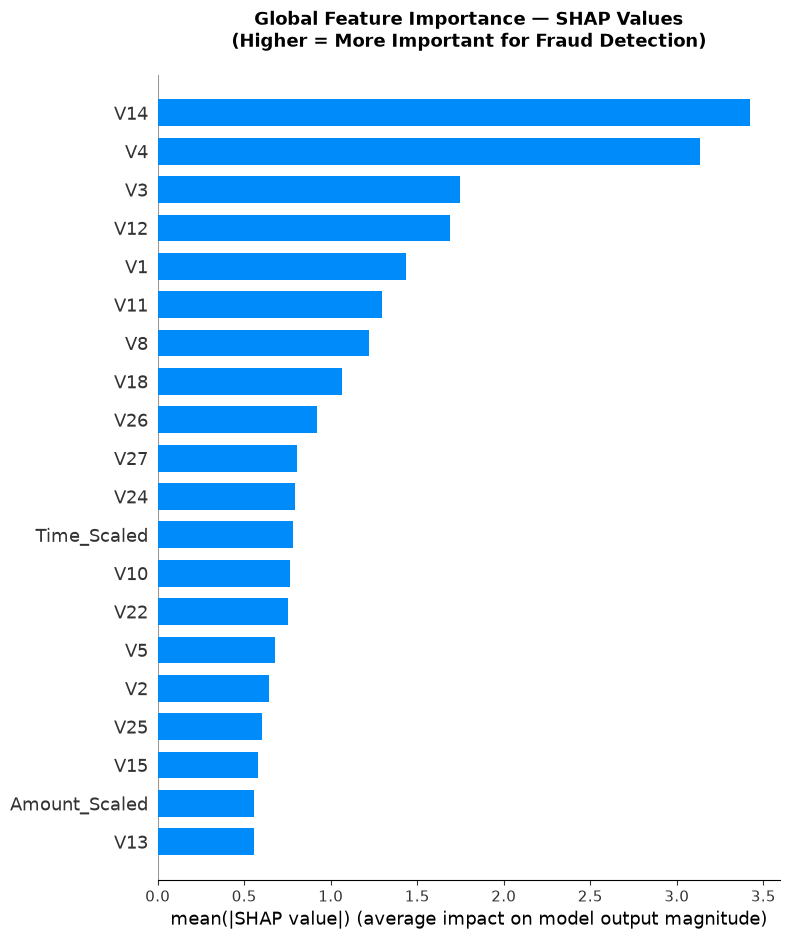

 Global importance plot saved

Top 10 Fraud Detection Features:
feature  mean_shap
    V14   3.425143
     V4   3.132039
     V3   1.748622
    V12   1.689164
     V1   1.432232
    V11   1.296126
     V8   1.219882
    V18   1.066777
    V26   0.923095
    V27   0.805452

 These are the features that matter most for fraud detection


In [3]:
print("Generating SHAP Summary Plot...")

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Global Feature Importance — SHAP Values\n(Higher = More Important for Fraud Detection)", 
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/shap_global_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Global importance plot saved")

# Print top features
feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_shap': np.abs(shap_values.values).mean(axis=0)}).sort_values('mean_shap', ascending=False)

print("\nTop 10 Fraud Detection Features:")
print("="*40)
print(feature_importance.head(10).to_string(index=False))
print("\n These are the features that matter most for fraud detection")

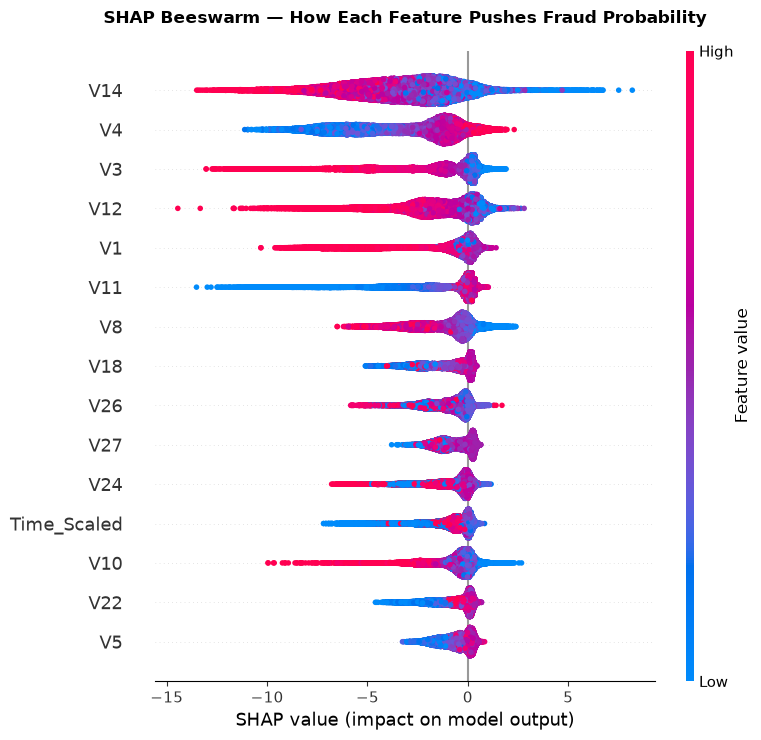

 Beeswarm plot saved

How to read this chart:
 Red = high feature value, Blue = low feature value
 Right side = pushes toward FRAUD
 Left side  = pushes toward LEGITIMATE


In [4]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — How Each Feature Pushes Fraud Probability",
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Beeswarm plot saved")
print("\nHow to read this chart:")
print(" Red = high feature value, Blue = low feature value")
print(" Right side = pushes toward FRAUD")
print(" Left side  = pushes toward LEGITIMATE")

Correctly caught fraud cases: 84

Case 1 — High Confidence Fraud
Index             : 1146
Fraud Probability : 1.0000 (100.0%)
Actual Label      : FRAUD


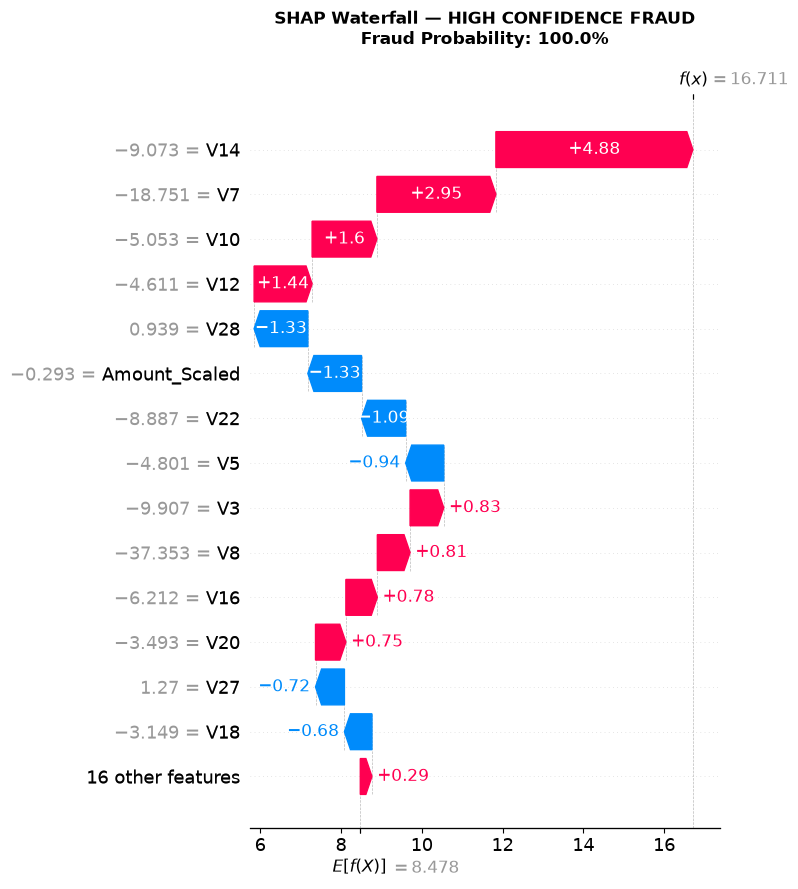

Fraud waterfall plot saved


In [6]:
# Find a high-confidence fraud prediction
import xgboost as xgb
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

# Get actual fraud cases the model caught
fraud_indices = np.where((y_test.values == 1) & (y_pred == 1))[0]
print(f"Correctly caught fraud cases: {len(fraud_indices)}")

# Pick the highest confidence fraud
best_fraud_idx = fraud_indices[np.argmax(y_prob[fraud_indices])]
fraud_prob = y_prob[best_fraud_idx]

print(f"\nCase 1 — High Confidence Fraud")
print(f"Index             : {best_fraud_idx}")
print(f"Fraud Probability : {fraud_prob:.4f} ({fraud_prob*100:.1f}%)")
print(f"Actual Label      : {'FRAUD' if y_test.values[best_fraud_idx]==1 else 'LEGIT'}")

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap_values[best_fraud_idx],
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — HIGH CONFIDENCE FRAUD\n"
          f"Fraud Probability: {fraud_prob*100:.1f}%",
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/shap_waterfall_fraud.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Fraud waterfall plot saved")

Case 2 — High Confidence Legitimate
Index             : 44502
Fraud Probability : 0.0000 (0.00%)
Actual Label      : LEGITIMATE


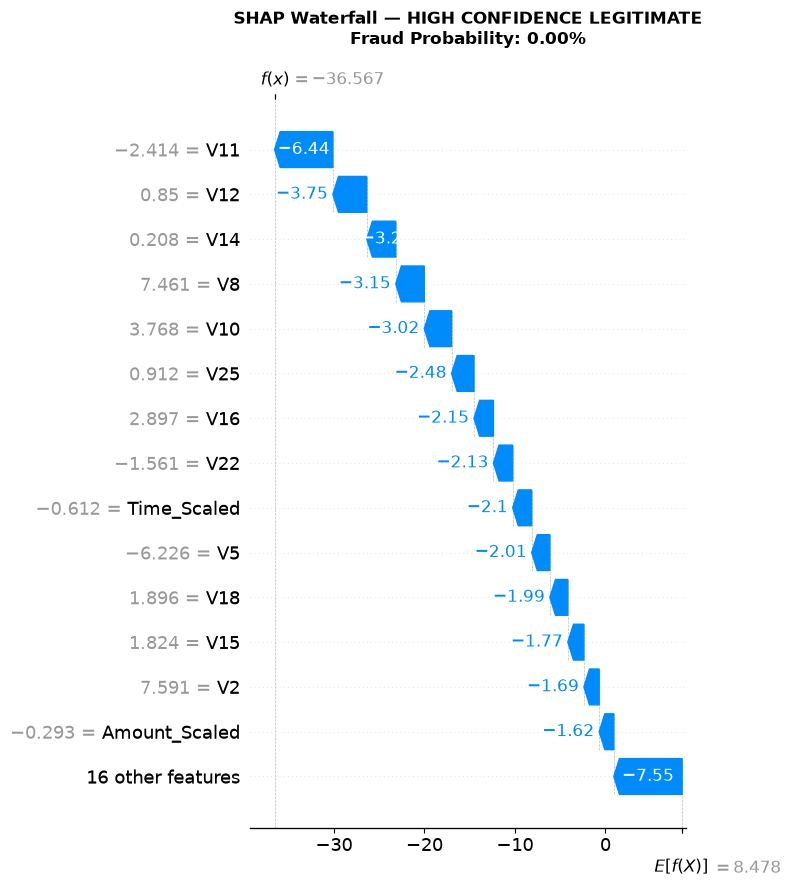

Legitimate waterfall plot saved


In [8]:
# Find a high-confidence legitimate transaction
legit_indices = np.where((y_test.values == 0) & (y_pred == 0))[0]
best_legit_idx = legit_indices[np.argmin(y_prob[legit_indices])]
legit_prob = y_prob[best_legit_idx]

print(f"Case 2 — High Confidence Legitimate")
print(f"Index             : {best_legit_idx}")
print(f"Fraud Probability : {legit_prob:.4f} ({legit_prob*100:.2f}%)")
print(f"Actual Label      : {'FRAUD' if y_test.values[best_legit_idx]==1 else 'LEGITIMATE'}")

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap_values[best_legit_idx],
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — HIGH CONFIDENCE LEGITIMATE\n"
          f"Fraud Probability: {legit_prob*100:.2f}%",
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/shap_waterfall_legit.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Legitimate waterfall plot saved")

Case 3 — Borderline Transaction (most interesting)
Index             : 49603
Fraud Probability : 0.4931 (49.3%)
Actual Label      : LEGITIMATE
Model Decision    : LEGITIMATE


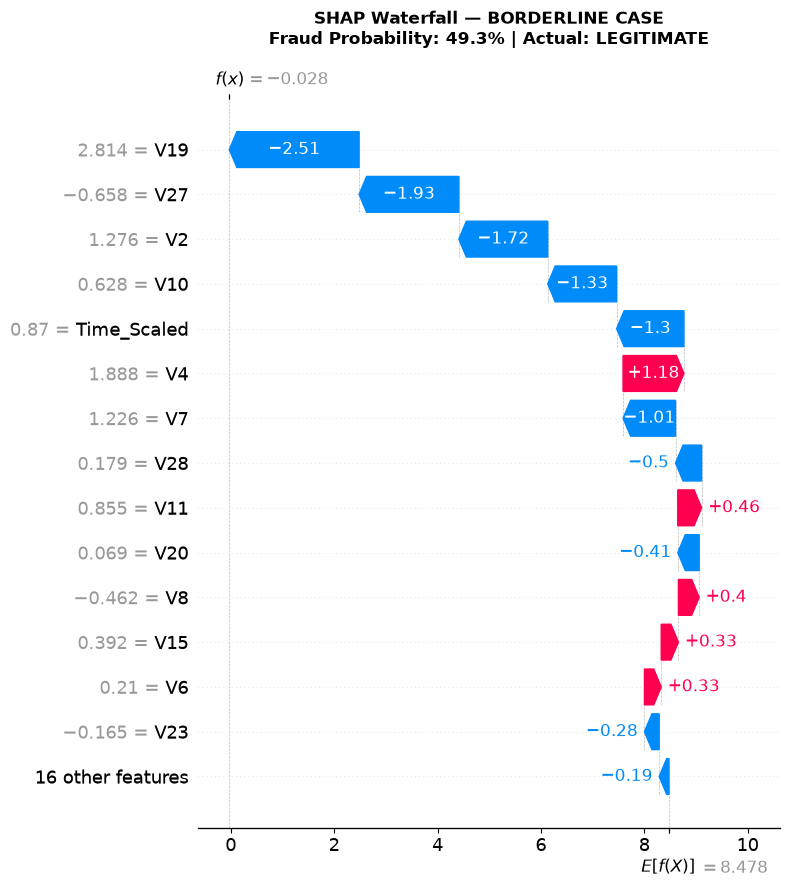

Borderline waterfall plot saved

This is the most powerful case to show at review
Shows SHAP explaining an uncertain decision transparently


In [9]:
# Find borderline case — probability closest to 0.5
all_probs = y_prob
borderline_idx = np.argmin(np.abs(all_probs - 0.5))
borderline_prob = y_prob[borderline_idx]
borderline_actual = y_test.values[borderline_idx]

print(f"Case 3 — Borderline Transaction (most interesting)")
print(f"Index             : {borderline_idx}")
print(f"Fraud Probability : {borderline_prob:.4f} ({borderline_prob*100:.1f}%)")
print(f"Actual Label      : {'FRAUD' if borderline_actual==1 else 'LEGITIMATE'}")
print(f"Model Decision    : {'FRAUD' if y_pred[borderline_idx]==1 else 'LEGITIMATE'}")

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap_values[borderline_idx],
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — BORDERLINE CASE\n"
          f"Fraud Probability: {borderline_prob*100:.1f}% | "
          f"Actual: {'FRAUD' if borderline_actual==1 else 'LEGITIMATE'}",
          fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/shap_waterfall_borderline.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Borderline waterfall plot saved")
print("\nThis is the most powerful case to show at review")
print("Shows SHAP explaining an uncertain decision transparently")

Top feature    : V14
Second feature : V4


<Figure size 1000x600 with 0 Axes>

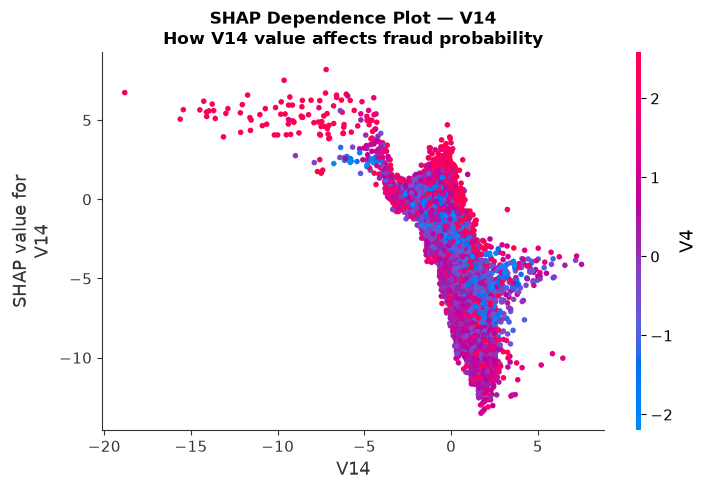

Dependence plot saved

Shows exactly how V14 drives fraud probability
This is what you explain to compliance teams


In [10]:
# Get top feature from SHAP
top_feature = feature_importance.iloc[0]['feature']
second_feature = feature_importance.iloc[1]['feature']

print(f"Top feature    : {top_feature}")
print(f"Second feature : {second_feature}")

plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_test,
    interaction_index=second_feature,
    show=False
)
plt.title(f"SHAP Dependence Plot — {top_feature}\n"
          f"How {top_feature} value affects fraud probability",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/shap_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Dependence plot saved")
print(f"\nShows exactly how {top_feature} drives fraud probability")
print(f"This is what you explain to compliance teams")

In [12]:
# Generate plain English explanation for each caught fraud
y_prob_full = xgb_model.predict_proba(X_test)[:, 1]
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
shap_df['fraud_probability'] = y_prob_full
shap_df['actual']            = y_test.values
shap_df['predicted']         = xgb_model.predict(X_test)

# For caught fraud cases — generate explanation
caught_fraud = shap_df[
    (shap_df['actual'] == 1) & (shap_df['predicted'] == 1)
].copy()

print(f"Generating compliance explanations for {len(caught_fraud)} caught fraud cases\n")
print("="*60)
print("SAMPLE COMPLIANCE REPORT — TOP 3 FRAUD CASES")
print("="*60)

feature_cols = X_test.columns.tolist()

for i, (idx, row) in enumerate(caught_fraud.head(3).iterrows()):
    feature_shap = row[feature_cols].abs().sort_values(ascending=False)
    top3 = feature_shap.head(3)
    
    print(f"\nTransaction #{i+1}")
    print(f"  Fraud Probability : {row['fraud_probability']*100:.1f}%")
    print(f"  Top fraud signals :")
    for feat, val in top3.items():
        direction = "↑ increases" if row[feat] > 0 else "↓ decreases"
        print(f"    • {feat}: SHAP={val:.4f} — {direction} fraud probability")
    print(f"  Decision          : FLAGGED FOR REVIEW")

print("\n" + "="*60)
print("This is what SHAP gives you — human-readable fraud explanations")
print("Compliance teams can audit every single flag")
print("Regulators accept this as explainable AI")

# Save SHAP dataframe
shap_df.to_csv(
    'D:/Projects/fraud-detection-shap-aws/reports/shap_scores.csv',
    index=False
)
print("\nSHAP scores saved to reports/shap_scores.csv")

Generating compliance explanations for 84 caught fraud cases

SAMPLE COMPLIANCE REPORT — TOP 3 FRAUD CASES

Transaction #1
  Fraud Probability : 100.0%
  Top fraud signals :
    • V14: SHAP=4.7190 — ↑ increases fraud probability
    • V7: SHAP=2.8792 — ↑ increases fraud probability
    • V10: SHAP=1.7701 — ↑ increases fraud probability
  Decision          : FLAGGED FOR REVIEW

Transaction #2
  Fraud Probability : 100.0%
  Top fraud signals :
    • V14: SHAP=4.8765 — ↑ increases fraud probability
    • V7: SHAP=2.9456 — ↑ increases fraud probability
    • V10: SHAP=1.6039 — ↑ increases fraud probability
  Decision          : FLAGGED FOR REVIEW

Transaction #3
  Fraud Probability : 100.0%
  Top fraud signals :
    • V14: SHAP=4.5949 — ↑ increases fraud probability
    • V7: SHAP=2.6452 — ↑ increases fraud probability
    • V10: SHAP=1.9915 — ↑ increases fraud probability
  Decision          : FLAGGED FOR REVIEW

This is what SHAP gives you — human-readable fraud explanations
Compliance t

In [14]:
import os

shap_folder = 'D:/Projects/fraud-detection-shap-aws/reports/shap_plots/'
plots = os.listdir(shap_folder)

print("="*50)
print("ALL SHAP PLOTS GENERATED")
print("="*50)
for plot in sorted(plots):
    print(f" {plot}")

print(f"\nTotal plots : {len(plots)}")
print("\nDay 5 complete — SHAP explainability fully built")
print("Ready for Day 6 — Behavioural Profiling + Graph Detection")

ALL SHAP PLOTS GENERATED
 amount_distribution.png
 class_imbalance.png
 cm_Isolation_Forest.png
 cm_LR_Balanced.png
 cm_LR_SMOTE.png
 cm_Logistic_Regression_Baseline.png
 cm_xgboost.png
 correlation_chart.png
 fraud_by_hour.png
 model_comparison.png
 pr_curve_xgboost.png
 shap_beeswarm.png
 shap_dependence.png
 shap_global_importance.png
 shap_waterfall_borderline.png
 shap_waterfall_fraud.png
 shap_waterfall_legit.png

Total plots : 17

Day 5 complete — SHAP explainability fully built
Ready for Day 6 — Behavioural Profiling + Graph Detection
